# Task 2: mini research task on a novel AI topic

**topic:** denoising diffusion models (DDPM and DDIM)
- DDPM: Denoising Diffusion Probabilistic Models
- DDIM: Denoising Diffusion Implicit Models

**technical sources:**
- Ho, Jonathan, Ajay Jain, and Pieter Abbeel: Denoising Diffusion Probabilistic Models from https://arxiv.org/abs/2006.11239
- Song, Jiaming, Chenlin Meng, and Stefano Ermon: Denoising Diffusion Implicit Models from https://arxiv.org/abs/2010.02502
- Hugging Face Diffusers documentation from https://huggingface.co/docs/diffusers/api/schedulers/ddpm

**Explain the problem the method is trying to solve, the core idea behind the method, and the main
architecture or training objective in your own words.**
<br>
<br>
**problem**
- Diffusion models are a type of generative model, meaning they try to learn how to create new data samples that look like real data, especially images. The main goal is to generate high-quality images without needing adversarial training like GANs (where two networks compete against eachother). Ho, Jain, and Abbeel describe diffusion models as models that learn an underlying process for turning noisy images back into structured, realistic ones, and they show that this approach can produce very strong image quality results. <br><br>The idea is to start with a real image, slowly add Gaussian noise until the image is almost pure noise, and then train a neural network to reverse that corruption process step by step. In the DDPM paper, the forward process is a fixed procedure that slowly adds Gaussian noise to an image until it becomes almost completely random. This part isn't learned, but rather the amount of noise added at each step is predefined. The reverse process is what the model learns: it takes a noisy image and gradually removes the noise step by step to recover a clear image. <br><br>A key issue, though, is that this reverse process usually takes many steps. Song, Meng, and Ermon explain that DDPMs can generate high-quality images, but they often require simulating a long Markov chain during sampling, which makes generation slow. This challenge is what motivated their DDIM work.
<br><br>
**core idea**
1. Forward diffusion: gradually destroy structure in the image by adding noise over many timesteps
2. Reverse diffusion: learn how to remove that noise step by step until a clean image is recovered

- In DDPM, the forward process is a fixed Markov chain, and the reverse process is another Markov chain with learned Gaussian transitions. Ho et al. define the reverse model as a chain that starts from noise and repeatedly predicts how to move toward a cleaner sample. <br><br>One useful detail from the paper is that the forward process has a closed-form way to sample a noisy version of an image at any timestep. That makes training efficient, because the model can randomly choose a timestep and learn to denoise from there instead of simulating the whole chain during training.<br><br>The Hugging Face scheduler documentation reflects this same idea in practical form where the scheduler has an add_noise function that adds noise to original samples according to a timestep, explicitly described as the forward diffusion process.
<br><br>
**main architecture/training objective**
- DDPM architecture:
  In Ho et al., the reverse process is represented using a U-Net backbone with group normalization, timestep conditioning through sinusoidal embeddings, and self-attention at selected resolutions. So the model is not just a plain CNN but is a U-Net-style denoiser that is told which diffusion step it is currently working on.

- DDPM training objective:
  The full model is originally defined using a variational bound, which is a mathematically correct way to train the model by approximating how well it explains the data. However, this objective is fairly complex and not very intuitive to work with. The authors found that they could simplify the training process by instead having the model directly predict the noise that was added to an image at a given step. This simpler objective is easier to implement and train, and Ho et al. reports very strong CIFAR-10 results with it.

  - the training loop is basically:
    - take a clean image,
    - choose a random timestep,
    - add the appropriate amount of Gaussian noise,
    - ask the model to predict the noise,
    - and update the model so its prediction gets closer to the true noise.

  - This is elegant because the model doesn't need to directly predict the whole clean image from scratch. It just learns, at many noise levels, how to identify and remove the corruption.
- DDIM doesn't change the neural network architecture; it keeps the same model (U-Net) but changes the sampling process (reverse diffusion path). Essentially, it's a different way of using the same model.
- DDIM training objective:
  A major idea in the DDIM paper is that DDIM keeps the same training procedure as DDPM. The change is not mainly in retraining a different model, but in using a more efficient sampling process. Song et al. generalize DDPM to a class of non-Markovian diffusion processes that still lead to the same training objective.

The effect of DDIM:
- DDPM sampling is powerful but slow because it usually uses many reverse denoising steps. DDIM is important because it shows that you can keep the same training setup but change the sampling path to make generation much faster.

- Song et al. describe DDIMs as a more efficient class of iterative implicit probabilistic models. Their main claim is that DDIMs can sample much faster than DDPMs while still producing high-quality outputs. They report speedups of about 10-50x in wall-clock sampling time, and they also note useful properties like latent-space interpolation and low-error reconstruction.

- Essentially:
  - DDPM: very standard step-by-step reverse diffusion, usually many steps
  - DDIM: a smarter reverse trajectory that can skip through the process more efficiently
  - This makes DDIM especially important for practical use, because even if a method produces great images, it is much harder to use in real settings if every sample takes a long time to generate.

**hands-on demo: simple DDPM vs DDIM comparison**
<br><br>
compares two reverse diffusion sampling methods using the same pretrained image generation pipeline and the same prompt
<br><br>
I will also vary the number of inference steps once to show the practical tradeoff discussed in the DDIM paper: DDIM is designed to sample faster, while the scheduler API lets us control how many denoising steps are used during generation.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

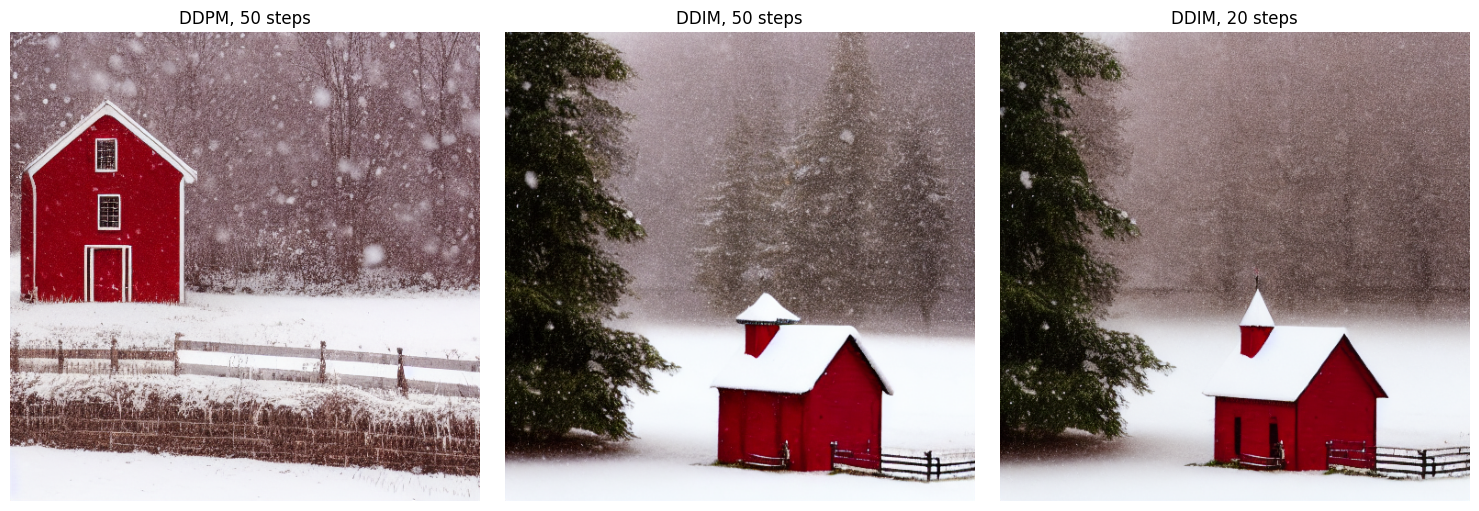

,Run,Scheduler,Inference steps,Runtimes,Prompt
0,1,DDPM,50,3.983117,a small red house in a snowy field
1,2,DDIM,50,2.311989,a small red house in a snowy field
2,3,DDIM,20,0.974881,a small red house in a snowy field


In [3]:
# install packages for diffusion pipeline, schedulers, and plotting
!pip -q install diffusers transformers accelerate torch

import torch
import matplotlib.pyplot as plt
import pandas as pd
# import pretrained image-generation pipeline, DDPM and DDIM style reverse diffusion schedulers
from diffusers import StableDiffusionPipeline, DDPMScheduler, DDIMScheduler

# connect to GPU for faster running
device = "cuda" if torch.cuda.is_available() else "cpu"

# load one standard pretrained diffusion pipeline onto the GPU; already trained diffusion model to be used for generation
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to(device)

# disable safety checker for simple demo
pipe.safety_checker = lambda images, **kwargs: (images, [False] * len(images))

# simple text propmt that will be used for all runs
prompt = "a small red house in a snowy field"
seed = 0

def generate_with_scheduler(pipe, scheduler_cls, num_steps, prompt, seed):
    """
    Generate one image using a chosen scheduler and a chosen number of inference steps.
    Swaps the scheduler inside the same pretrained pipeline and generates an image.

    Inputs:
    - pipe: pretrained stable diffusion pipeline
    - scheduler_cls: which reverse diffusion scheduler to use
    - num_steps: number of denoising/inference steps to run
    - seed: random seed for reproducibility
    """
    # replace the pipeline's current scheduler with the chosen scheduler for this run (where we switch between DDPM and DDIM sampling)
    pipe.scheduler = scheduler_cls.from_config(pipe.scheduler.config)
    # create seeded random number generator to make results reproducible
    generator = torch.Generator(device=device).manual_seed(seed)
    # run pretrained diffusion pipeline
    image = pipe(
        prompt,
        num_inference_steps=num_steps,
        generator=generator
    ).images[0]

    return image
"""
Experimental runs:
the pretrained model and prompt stay the same. I change the scheduler (DDPM vs DDIM) and the number of inference steps for experimentation
so we can observe how the reverse diffusion method and step count affect the final image.
"""
import time
# run 1: DDPM scheduler with 50 inference steps (more standard sampling condition)
start = time.time()
img_ddpm_50 = generate_with_scheduler(
    pipe, DDPMScheduler, 50, prompt, seed
)
time_ddpm_50 = time.time() - start

# run 2: DDIM scheduler, 50 steps (keeps number of steps the same, but changes scheduler)
start = time.time()
img_ddim_50 = generate_with_scheduler(
    pipe, DDIMScheduler, 50, prompt, seed
)
time_ddim_50 = time.time() - start

# run 3: DDIM scheduler, 20 steps (keep DDIM scheduler the same, but run with less stes)
start = time.time()
img_ddim_20 = generate_with_scheduler(
    pipe, DDIMScheduler, 20, prompt, seed
)
time_ddim_20 = time.time() - start

# visualize outputs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_ddpm_50)
axes[0].set_title("DDPM, 50 steps")
axes[0].axis("off")

axes[1].imshow(img_ddim_50)
axes[1].set_title("DDIM, 50 steps")
axes[1].axis("off")

axes[2].imshow(img_ddim_20)
axes[2].set_title("DDIM, 20 steps")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# supporting table
results_table = pd.DataFrame({
    "Run": ["1", "2", "3"],
    "Scheduler": ["DDPM", "DDIM", "DDIM"],
    "Inference steps": [50, 50, 20],
    "Runtimes": [time_ddpm_50, time_ddim_50, time_ddim_20],
    "Prompt": [prompt, prompt, prompt]
})
results_table

**analysis**
<br>
All three images were generated from the same prompt but using different sampling methods and numbers of denoising steps.

DDPM 50 steps vs. DDIM 50 steps:
- both produce high-quality images, but with noticeable differences. The DDPM image has finer detail and structure, with finer details on the house, the snow, the trees in the background, and especially the fence and brick wall. The DDIM image, while still clear and realistic, is less refined, slightly softer, and less sharp. With the same number of steps, DDPM produces a clearer image with more robust details. However, DDIM is meaningfully faster, which emphasizes the increased efficiency of DDIM while still preserving a high standard of quality. It's important to note how the produced image for DDPM vs DDIM is different; even though both methods use the same trained model, following different reverse diffusion paths results in different image output.

DDIM 50 steps vs DDIM 20 steps:
- DDIM 50 has sharper details than DDIM 20, though both are convinving images.The images are nearly identical, with the one key difference being the level of refinement/thin detailing in the background trees. DDIM 50 achieves a greater level of sharpness in the snow and background, while the 20-step captures a softer main idea. The speed of DDIM with 20 steps is meaningfully quicker than that of DDIM with 50 steps, which supports the idea from the DDIM paper that fewer steps can make generation faster, but may come with a small tradeoff in quality.

From this experiment, we can see:
- The reverse diffusion process (sampling) is what actually generates the image. Diffusion models are not fully deterministic, as even with the same model and inputs, different sampling rules produced different images.
- The number of steps and the sampling method both affect the balance between image quality and efficiency.
- DDIM can produce reasonable images with fewer steps, which explains why it is useful for speeding up diffusion models in practice.


**Discuss at least two limitations, risks, or open challenges related to the method**
<br><br>
One major limitation of diffusion models is that image generation can still be computationally expensive, especially when using many denoising steps. As shown in the DDPM paper, generating high-quality images often requires running the reverse diffusion process over many timesteps, which can be slow. Although DDIM improves this by allowing fewer steps, there is still a tradeoff between speed and image quality, as seen in the experiment where fewer steps led to slightly less detailed results.

Another challenge is that the output quality depends heavily on design choices like the noise schedule and sampling method. The Hugging Face scheduler documentation shows that different schedulers and timestep settings control how noise is added and removed during the process. This means that even with the same trained model, changing these settings can lead to noticeably different outputs. Because of this, it can be difficult to know which configuration will work best without thorough experimentation.

A further limitation is that diffusion models can produce inconsistent or unpredictable results, even when using the same prompt. In the experiment, the generated images had noticeably different compositions and visual details, even though the input prompt and seed were the same. This reflects the probabilistic nature of the sampling process and the fact that different schedulers follow different paths from noise to image. As a result, diffusion models can be difficult to control precisely, which may be a problem in applications where consistency is important.

**Propose one concrete extension, improvement, or follow-up experiment that you would pursue
next**
<br><br>
A concrete follow-up experiment I would pursue next is a more systematic comparison of DDPM and DDIM across several different numbers of inference steps, such as 10, 20, 50, and 100 steps, while keeping the same prompt and random seed. This would make the tradeoff between speed and image quality much clearer than the small demo I used, because it would show how image detail changes as the reverse diffusion process gradually becomes significantly shorter or longer.

I would use the same pretrained pipeline and compare the outputs side by side in a table or figure. Then I would look for patterns such as when the image starts to lose important detail, when the quality stops improving much, and whether DDIM continues to give reasonable results at lower step counts than DDPM.

This would be a useful next step because it would move beyond a one-time example and give a clearer picture of how practical scheduler and timestep choices affect diffusion model performance.